In [9]:
# imports
import numpy as py
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
import shutil

In [10]:
# File path
file_path = os.path.join(os.getcwd(), "data", "heart_disease_dataset.csv")

In [11]:
if file_path:
  df = pd.read_csv(file_path)
  print(df.head())
else:
  print("No file")

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


# EDA

In [ ]:
# Analisis awal

print(df.shape)
print(df.describe())
print(df.info())

(1025, 14)
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000000   275.00000   
max      77.000000     1.000000     3.000000   200.000000   564.00000   

               fbs      restecg      thalach        exang      oldpeak  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.000000   
mean      0.149268     0.529756   149.114146     0.336585     1.071512   
std       0.356527     0.527878    23.005724     0.472772     1.175053   
min       0.000000     0.000000    

In [ ]:
# Jumlah nilai dalam setiap kolom

for i in df.columns:
  print("----------")
  print( df[i].value_counts(dropna=False))

----------
age
58    68
57    57
54    53
59    46
52    43
51    39
56    39
62    37
60    37
44    36
64    34
63    32
41    32
61    31
67    31
55    30
65    27
53    26
43    26
42    26
45    25
66    25
46    23
48    23
50    21
47    18
49    17
35    15
70    14
39    14
38    12
68    12
71    11
40    11
69     9
34     6
37     6
29     4
76     3
77     3
74     3
Name: count, dtype: int64
----------
sex
1    713
0    312
Name: count, dtype: int64
----------
cp
0    497
2    284
1    167
3     77
Name: count, dtype: int64
----------
trestbps
120    128
130    123
140    107
110     64
150     55
138     45
128     39
125     38
160     36
112     30
132     28
118     24
108     21
124     20
135     20
145     17
152     17
134     17
170     15
100     14
122     14
136     11
180     10
126     10
142      9
115      9
105      9
146      8
148      7
178      7
94       7
144      6
102      6
114      4
117      4
154      4
123      4
200      4
165      4
106   

In [ ]:
# Tentukan jumlah data, duplikat, dan missing values

print("Data shape:", df.shape)
print("Duplicates:", df.duplicated().sum())
print("Missing values:")
print(df.isna().sum())

Data shape: (1025, 14)
Duplicates: 723
Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


Terdapat 1025 baris data dan 14 kolom/fitur. fitur terdiri dari:

    - age      : Numerik     : [29,77], int
    - sex      : Kategorikal : {0,1}
    - cp       : Kategorikal : {0,1,2,3}
    - trestbps : Numerik     : [94,200], int
    - chol     : Numerik     : [126,564], int
    - fbs      : Kategorikal : {0,1}
    - restecg  : Kategorikal : {0,1,2}
    - thalach  : Numerik     : [71,202], int
    - exang    : Kategorikal : {0,1}
    - oldpeak  : Numerik     : [0.0,6.2], float
    - slope    : Kategorikal : {0,1,2}
    - ca       : Kategorikal : {0,1,2,3,4}
    - thal     : Kategorikal : {0,1,2,3}
    - target   : Kategorikal : {0,1}

Tidak terdapat sel `na`, tapi terdapat 723 baris duplikat

Berikut adalah tabel detail perkiraan informasi fitur dan nilainya.

| Feature | Description | Value Encoding / Units | Dataset Range |
| :--- | :--- | :--- | :--- |
| `age` | Patient age | Years | 29 – 77 |
| `sex` | Biological sex | `0` = Female<br>`1` = Male | 0 or 1 |
| `cp` | Chest pain type | `0` = Typical Angina<br>`1` = Atypical Angina<br>`2` = Non-anginal Pain<br>`3` = Asymptomatic | 0 – 3 |
| `trestbps` | Resting blood pressure | mm Hg (on hospital admission) | 94 – 200 |
| `chol` | Serum cholesterol | mg/dl | 126 – 564 |
| `fbs` | Fasting blood sugar > 120 mg/dl | `0` = False ($\le$ 120 mg/dl)<br>`1` = True (> 120 mg/dl) | 0 or 1 |
| `restecg` | Resting ECG results | `0` = Normal<br>`1` = ST-T Wave Abnormality<br>`2` = Left Ventricular Hypertrophy | 0 – 2 |
| `thalach` | Maximum heart rate | Beats per minute achieved during exercise | 71 – 202 |
| `exang` | Exercise-induced angina | `0` = No<br>`1` = Yes | 0 or 1 |
| `oldpeak` | ST depression | ST depression induced by exercise relative to rest | 0.0 – 6.2 |
| `slope` | Peak exercise ST segment slope | `0` = Upsloping<br>`1` = Flat<br>`2` = Downsloping | 0 – 2 |
| `ca` | Fluoroscopy vessel count | Number of major vessels (0–4) colored by fluoroscopy | 0 – 4 |
| `thal` | Thallium stress test result | `0` = Null/Error<br>`1` = Fixed Defect<br>`2` = Normal<br>`3` = Reversible Defect | 0 – 3 |
| `target` | Disease diagnostic status | `0` = Absence of heart disease (< 50% diameter narrowing)<br>`1` = Presence of heart disease (> 50% diameter narrowing) | 0 or 1 |

Detail informasi bisa saja meleset karena tidak ada konfensi (*convention*) yang memastikan informasi seperti `sex=1` artinya pria.

Adapun referensi yang kami pakai untuk menentukan arti fitur dan nilainya adalah:

* https://www.researchgate.net/publication/391737364_A_Machine_Learning-Based_Framework_for_Heart_Disease_Diagnosis_Using_a_Comprehensive_Patient_Cohort

* https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

* https://archive.ics.uci.edu/dataset/45/heart+disease

In [ ]:
# Deskripsi data setelah menghapus duplikat

print("Before:", len(df))
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()
print("After:", len(df))

print(df.shape)
print(df.describe())

Before: 1025
Duplicates: 723
After: 302
(302, 14)
             age         sex          cp    trestbps        chol         fbs  \
count  302.00000  302.000000  302.000000  302.000000  302.000000  302.000000   
mean    54.42053    0.682119    0.963576  131.602649  246.500000    0.149007   
std      9.04797    0.466426    1.032044   17.563394   51.753489    0.356686   
min     29.00000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     48.00000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     55.50000    1.000000    1.000000  130.000000  240.500000    0.000000   
75%     61.00000    1.000000    2.000000  140.000000  274.750000    0.000000   
max     77.00000    1.000000    3.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  302.000000  302.000000  302.000000  302.000000  302.000000  302.000000   
mean     0.526490  149.569536    0.327815    1.043046    1.397351  

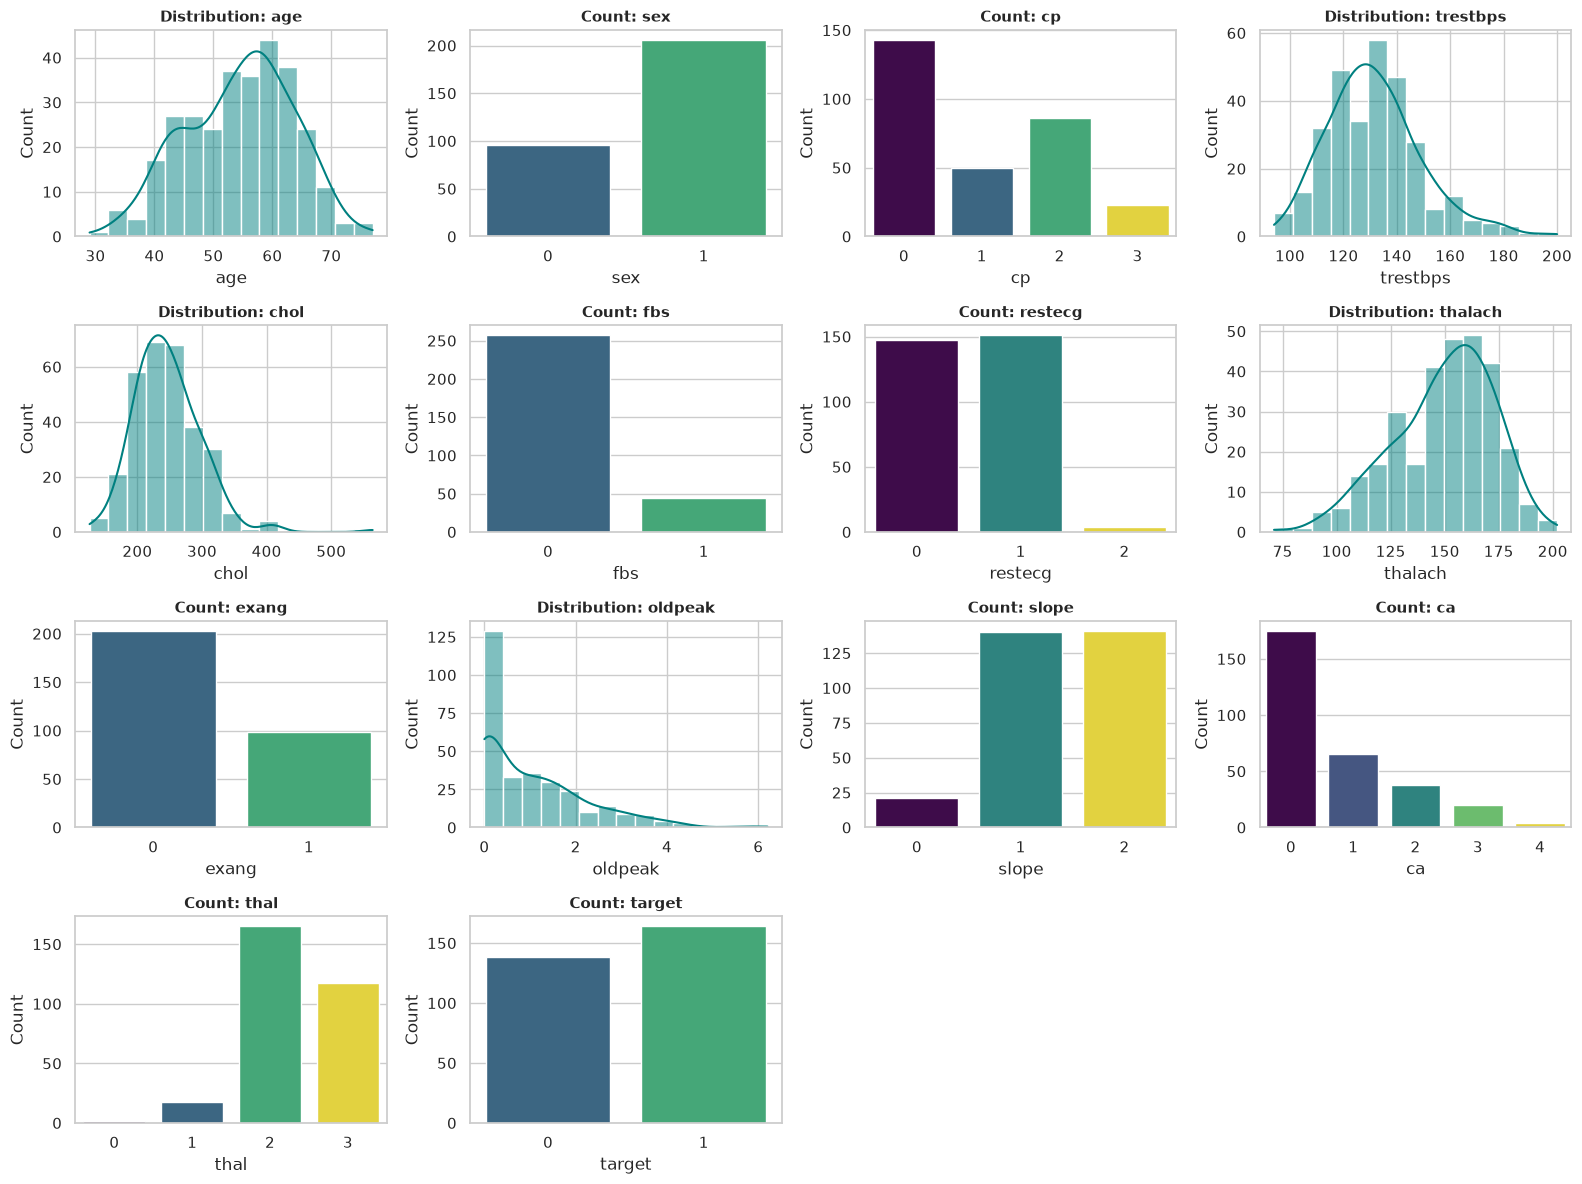

In [ ]:
# Visualisasi data

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows= 4, ncols=4,figsize=(16,12))
axes = axes.flatten()
feat = df.columns.tolist()
for i, col in enumerate(feat):
  if df[col].nunique() <=6:
    sns.countplot(data = df, x=col, ax=axes[i], palette="viridis", hue=col)
    if axes[i].get_legend() is not None:
      axes[i].get_legend().remove()
    axes[i].set_title(f'Count: {col}', fontsize=11, fontweight='bold')
  else:
    sns.histplot(df[col],kde=True, ax=axes[i], color='teal', bins=15)
    axes[i].set_title(f'Distribution: {col}', fontsize=11, fontweight='bold')
  axes[i].set_xlabel(col)
  axes[i].set_ylabel('Count')
for j in range(len(feat), len(axes)):
  fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

Secara keseluruhan, variabel target (`target`) memiliki proporsi kelas yang seimbang (*balanced*). Namun, hampir seluruh fitur kategorikal pendukung mengalami ketidakseimbangan kelas (*class imbalance*) dengan tingkat deviasi bervariasi. Pada fitur numerik/kontinu, sebagian besar menunjukkan kemiringan distribusi (*skewed*).

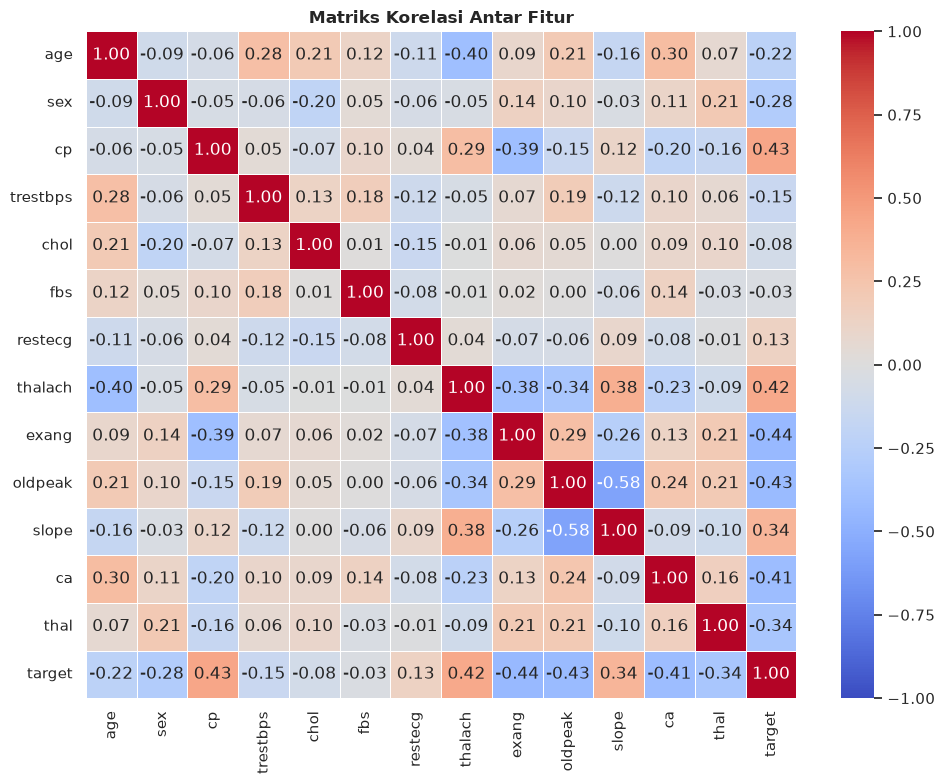

In [ ]:
# Matriks korelasi antar fitur

corr = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title('Matriks Korelasi Antar Fitur', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Berdasarkan matriks korelasi Pearson, fitur `exang` (-0.44), `cp` (0.43), `oldpeak` (-0.43), `thalach` (0.42), dan `ca` (-0.41) memiliki korelasi linier terkuat terhadap variabel target. Selain itu, `fitur slope` (0.34) dan `thal` (-0.34) memberikan kontribusi moderat. Sebaliknya, `fbs` (-0.03) dan `chol` (-0.08) memiliki korelasi linier yang sangat lemah. Perlu diingat bahwa antar-fitur independen terdapat multikolinearitas sedang, terutama antara slope dan oldpeak ($r = -0.58$)

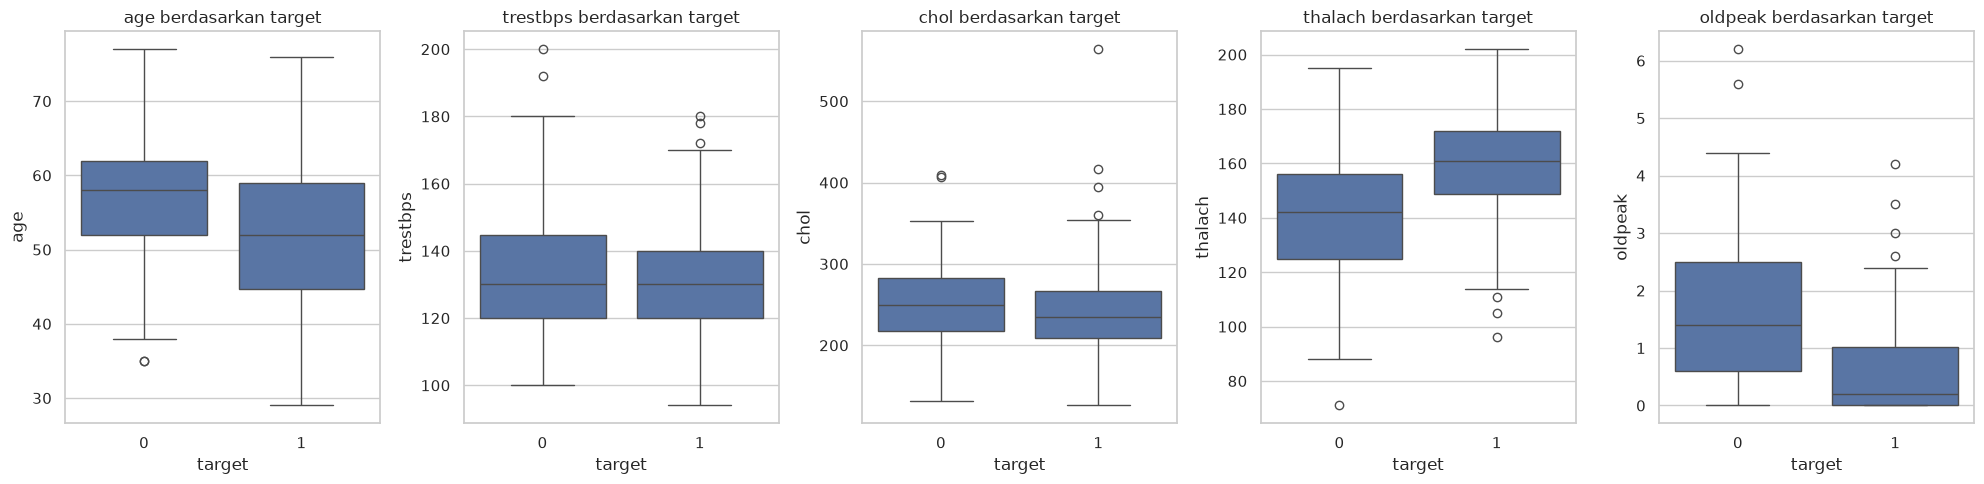

In [ ]:
# Boxplot untuk fitur numerik berdasarkan target

numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, feature in enumerate(numeric_features):
  sns.boxplot(data=df, x='target', y=feature, ax=axes[i])
  axes[i].set_title(f'{feature} berdasarkan target')

plt.tight_layout()
plt.show()

Boxplot digunakan untuk membandingkan distribusi fitur numerik antara target = 0 dan target = 1. Dari visualisasi terlihat bahwa terdapat perbedaan distribusi pada beberapa fitur antara kedua kelompok target. Perbedaan yang cukup terlihat terdapat pada `thalach` dan `oldpeak`, di mana kelompok target = 1 cenderung memiliki nilai `thalach` yang lebih tinggi dan `oldpeak` yang lebih rendah dibandingkan kelompok target = 0. Sementara itu, distribusi `trestbps` dan `chol` antar kedua kelompok terlihat lebih berdekatan.

Deteksi outlier dilakukan menggunakan metode IQR (batas bawah = Q1 - 1.5×IQR, batas atas = Q3 + 1.5×IQR) pada fitur numerik. Hasilnya:

- `age`: tidak ada outlier
- `trestbps`: 9 outlier (2.98%), seluruhnya berada di atas batas atas (170)
- `chol`: 5 outlier (1.66%), seluruhnya berada di atas batas atas (~370)
- `thalach`: 1 outlier (0.33%), di bawah batas bawah (~84)
- `oldpeak`: 5 outlier (1.66%), seluruhnya berada di atas batas atas (4.0)

Secara umum jumlah outlier pada tiap fitur relatif kecil (di bawah 3% dari data), sehingga tidak mengindikasikan kesalahan input yang masif. Outlier pada `trestbps` dan `chol` konsisten dengan kondisi medis ekstrem (tekanan darah/kolesterol sangat tinggi) yang secara klinis mungkin terjadi, sehingga tidak langsung dihapus melainkan perlu dipertimbangkan lebih lanjut pada tahap preprocessing (misalnya capping atau mempertahankannya jika model yang dipakai robust terhadap outlier).

In [21]:
# Deteksi outlier (metode IQR) untuk fitur numerik

outlier_summary = []
for feature in numeric_features:
  q1 = df[feature].quantile(0.25)
  q3 = df[feature].quantile(0.75)
  iqr = q3 - q1
  lower = q1 - 1.5 * iqr
  upper = q3 + 1.5 * iqr
  outliers = df[(df[feature] < lower) | (df[feature] > upper)]
  outlier_summary.append({
    'feature': feature,
    'lower_bound': lower,
    'upper_bound': upper,
    'n_outliers': len(outliers),
    'pct_outliers': round(len(outliers) / len(df) * 100, 2)
  })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,feature,lower_bound,upper_bound,n_outliers,pct_outliers
0,age,28.500,80.500,0,0.00
1,trestbps,90.000,170.000,9,2.98
2,chol,115.375,370.375,5,1.66
3,thalach,84.125,215.125,1,0.33
4,oldpeak,-2.400,4.000,5,1.66


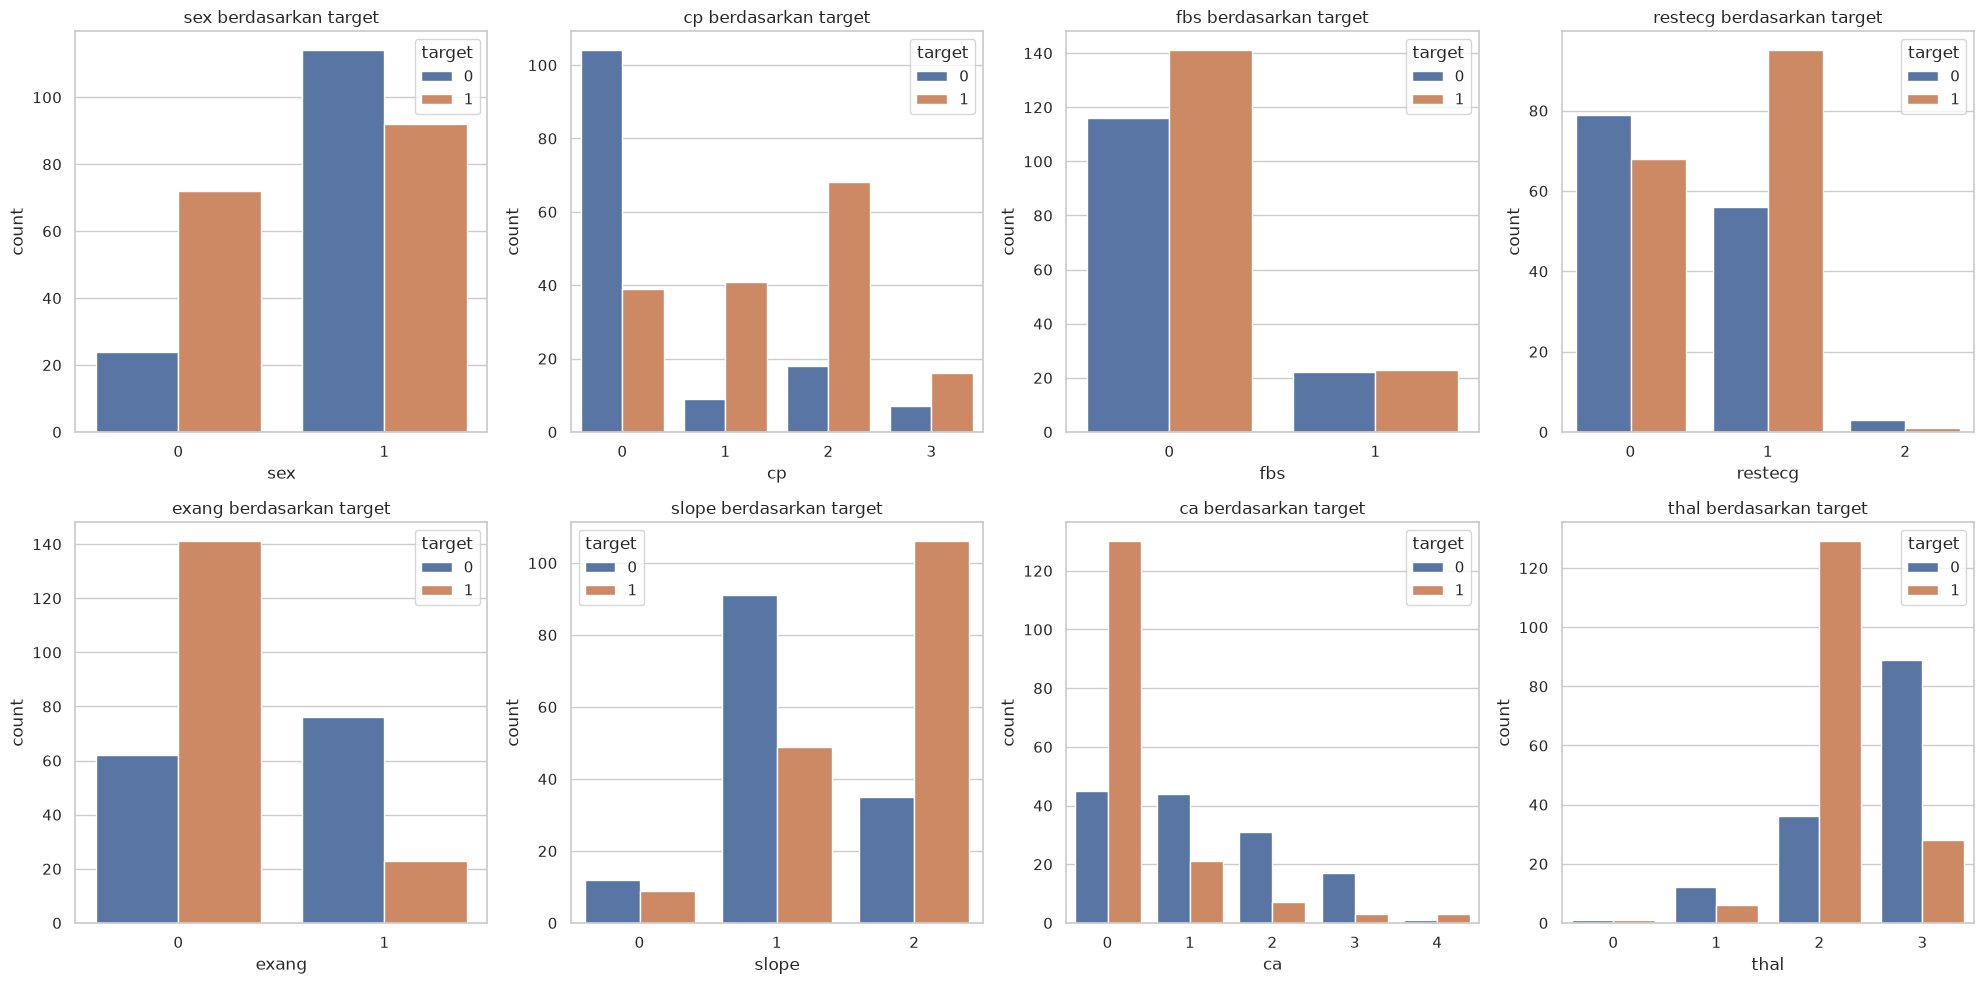

In [ ]:
# Countplot untuk fitur kategorikal berdasarkan target

categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
  sns.countplot(data=df, x=feature, hue='target', ax=axes[i])
  axes[i].set_title(f'{feature} berdasarkan target')

plt.tight_layout()
plt.show()

Countplot digunakan untuk membandingkan jumlah data target = 0 dan target = 1 pada setiap kategori fitur kategorikal, seperti `sex`, `cp`, `fbs`, `restescg`, `exang`, `slope`, `ca`, dan `thal`. Visualisasi ini membantu melihat apakah distribusi target berbeda pada kategori tertentu. Dari grafik terlihat bahwa komposisi target tidak selalu sama pada beberapa kategori. Beberapa kategori menunjukkan jumlah target = 1 yang lebih dominan, sedangkan kategori lainnya lebih banyak memiliki target = 0. Hal ini menunjukkan adanya pola perbedaan distribusi target berdasarkan kategori fitur, meskipun pola tersebut tidak dapat langsung diartikan sebagai hubungan sebab-akibat.

In [ ]:
# Statistik deskriptif

df.groupby('target')[numeric_features].agg(['mean', 'median', 'std'])

age                     trestbps                          chol  \
             mean median       std        mean median        std        mean   
target                                                                         
0       56.601449   58.0  7.962082  134.398551  130.0  18.729944  251.086957   
1       52.585366   52.0  9.511957  129.250000  130.0  16.204739  242.640244   

                             thalach                     oldpeak         \
       median        std        mean median        std      mean median   
target                                                                    
0       249.0  49.454614  139.101449  142.0  22.598782  1.585507    1.4   
1       234.5  53.456580  158.378049  161.0  19.199080  0.586585    0.2   

                  
             std  
target            
0       1.300340  
1       0.781734

Statistik deskriptif digunakan untuk membandingkan nilai mean, median, dan standar deviasi fitur numerik pada target = 0 dan target = 1. Hasilnya, `age`, `trestbps`, dan `chol` memiliki mean lebih tinggi pada target = 0, sedangkan `thalach` lebih tinggi pada target = 1. `oldpeak` juga menunjukkan perbedaan, yaitu 1.59 pada target = 0 dan 0.59 pada target = 1.